Phase 3: Exploratory Data Analysis
Goal: understand price/return/volatility behavior, confirm volatility clustering, and identify which features look predictive. Figures are saved to reports/figures/.

In [5]:
import sys
!{sys.executable} -m pip install seaborn statsmodels

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB 991.0 kB/s eta 0:00:12
   ---------------------------------------- 0.1/11.3 MB 1.3 MB/s eta 0:00:09
    --------------------------------------- 0.2/11.3 MB 2.1 MB/s eta 0:00:06
   - -------------------------------------- 0.4/11.3 MB 2.1 MB/s eta 0:00:06
   - -------------------------------------- 0.5/11.3 MB 2.2 MB/s eta 0:00:05
   -- ------------------------------------- 0.8/11.3 MB 3.1 MB/s eta 0:00:04
   --- ------------------------------------ 0.9/11.3 MB 3.2 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.3 MB 3.0 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/11.3 MB 3


[notice] A new release of pip is available: 24.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Ensure output dir
os.makedirs('../reports/figures', exist_ok=True)

# Load features
df = pd.read_csv('../data/processed/nsei_features.csv', parse_dates=['Date'], index_col='Date')
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
display(df.head(3))

Shape: (1612, 35)
Date range: 2020-03-13 → 2026-09-23


,Close,High,Low,Open,Volume,Return,High_Low_Range,Volume_Change,Return_lag1,Return_lag2,...,Close_MA50_ratio,RSI_14,MACD,MACD_signal,MACD_hist,ATR_14,Volume_MA_5,Volume_MA_20,Volume_ratio,Target_Volatility
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,9955.200195,10159.400391,8555.150391,9107.599609,1388000,0.037358,1604.250000,0.033122,-0.086669,0.000665,...,0.841584,17.264956,-503.818546,-327.371468,-176.447078,432.635603,1465300.0,830450.0,1.671383,0.051573
2020-03-16,9197.400391,9602.200195,9165.099609,9587.799805,897700,-0.079174,437.100586,-0.353242,0.037358,-0.086669,...,0.781598,14.935650,-592.255936,-380.348361,-211.907575,469.967843,1282640.0,850275.0,1.055776,0.070504
2020-03-17,8967.049805,9403.799805,8915.599609,9285.400391,935600,-0.025364,488.200195,0.042219,-0.079174,0.037358,...,0.766268,14.184131,-673.170680,-438.912825,-234.257855,497.471470,1156660.0,865915.0,1.080476,0.076073


3.1 Price Trend
Plot Close with 20-day and 50-day moving averages to identify trends and turning points.

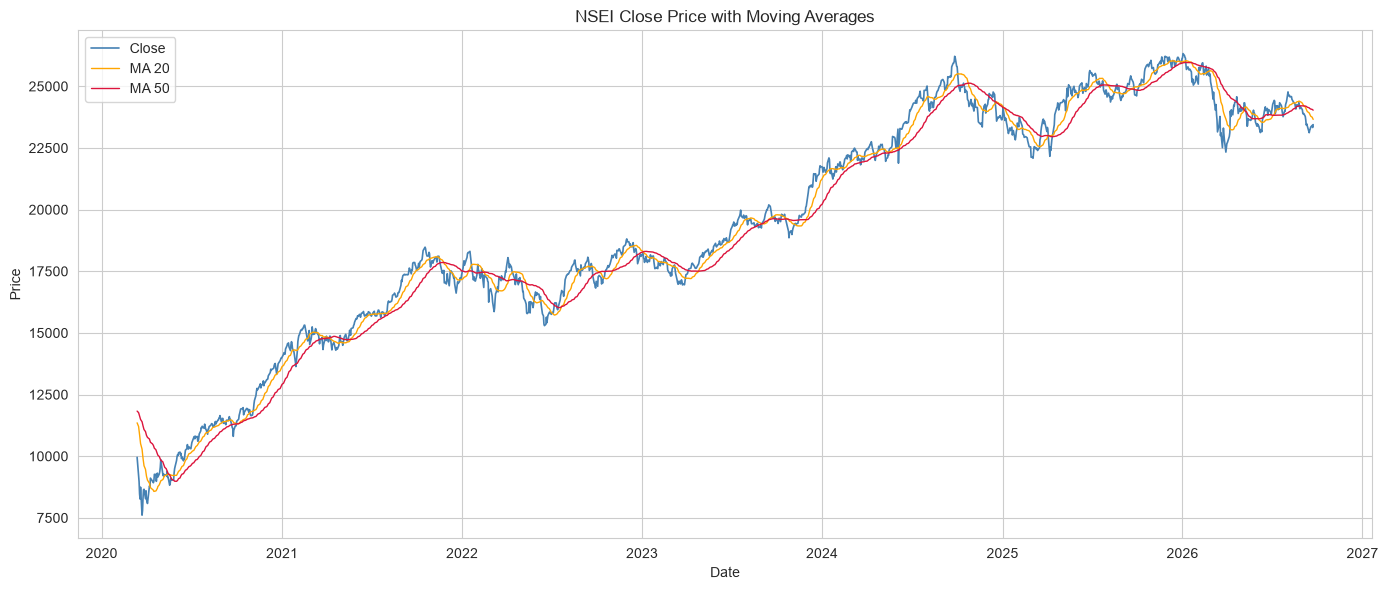

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], label='Close', color='steelblue', linewidth=1.2)
ax.plot(df.index, df['MA_20'], label='MA 20', color='orange', linewidth=1)
ax.plot(df.index, df['MA_50'], label='MA 50', color='crimson', linewidth=1)

ax.set_title('NSEI Close Price with Moving Averages')
ax.set_xlabel('Date'); ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_price_trend.png', dpi=120)
plt.show()

3.2 Returns Distribution
Histogram + boxplot to check skewness, fat tails, and extreme days.

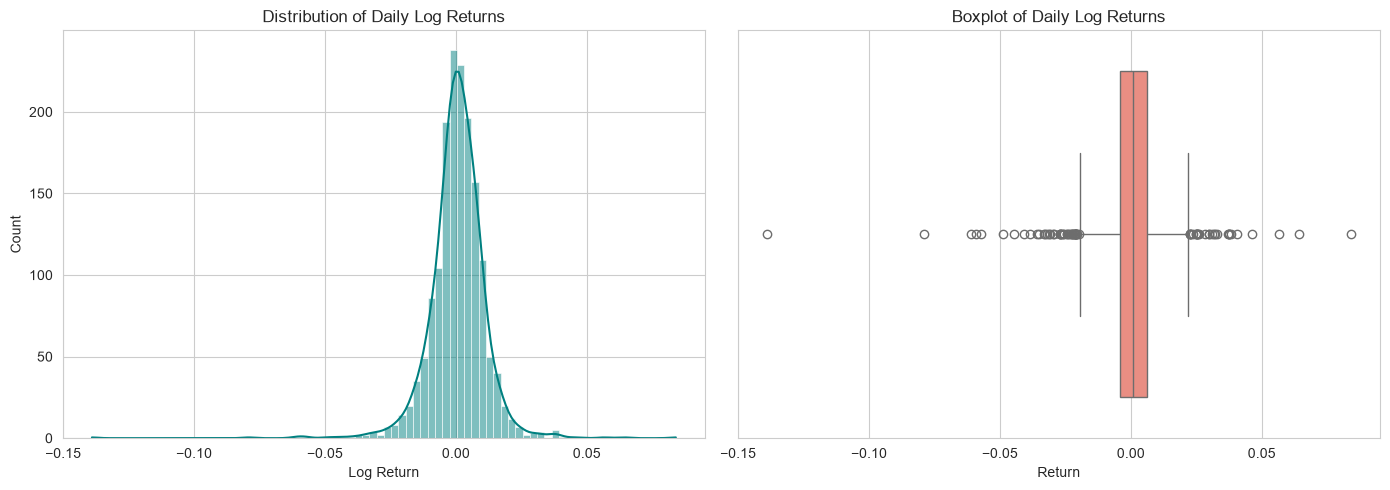

Mean:   0.000551
Std:    0.011019
Skew:   -1.4168
Kurt:   22.7452 (excess, Normal = 0)

Top 3 positive return days:


Date
2020-04-07    0.084003
2020-03-25    0.064145
2020-03-20    0.056691
Name: Return, dtype: float64

Top 3 negative return days:


Date
2020-03-23   -0.139038
2020-03-16   -0.079174
2024-06-04   -0.061124
Name: Return, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['Return'], bins=80, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Daily Log Returns')
axes[0].set_xlabel('Log Return')

# Boxplot
sns.boxplot(x=df['Return'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Daily Log Returns')

plt.tight_layout()
plt.savefig('../reports/figures/02_returns_distribution.png', dpi=120)
plt.show()

# Stats
print(f"Mean:   {df['Return'].mean():.6f}")
print(f"Std:    {df['Return'].std():.6f}")
print(f"Skew:   {df['Return'].skew():.4f}")
print(f"Kurt:   {df['Return'].kurtosis():.4f} (excess, Normal = 0)")

# Extreme days
print("\nTop 3 positive return days:")
display(df['Return'].nlargest(3))
print("Top 3 negative return days:")
display(df['Return'].nsmallest(3))

3.3 Volatility Over Time
Plot rolling volatility (5/10/20-day) to identify calm vs turbulent regimes.

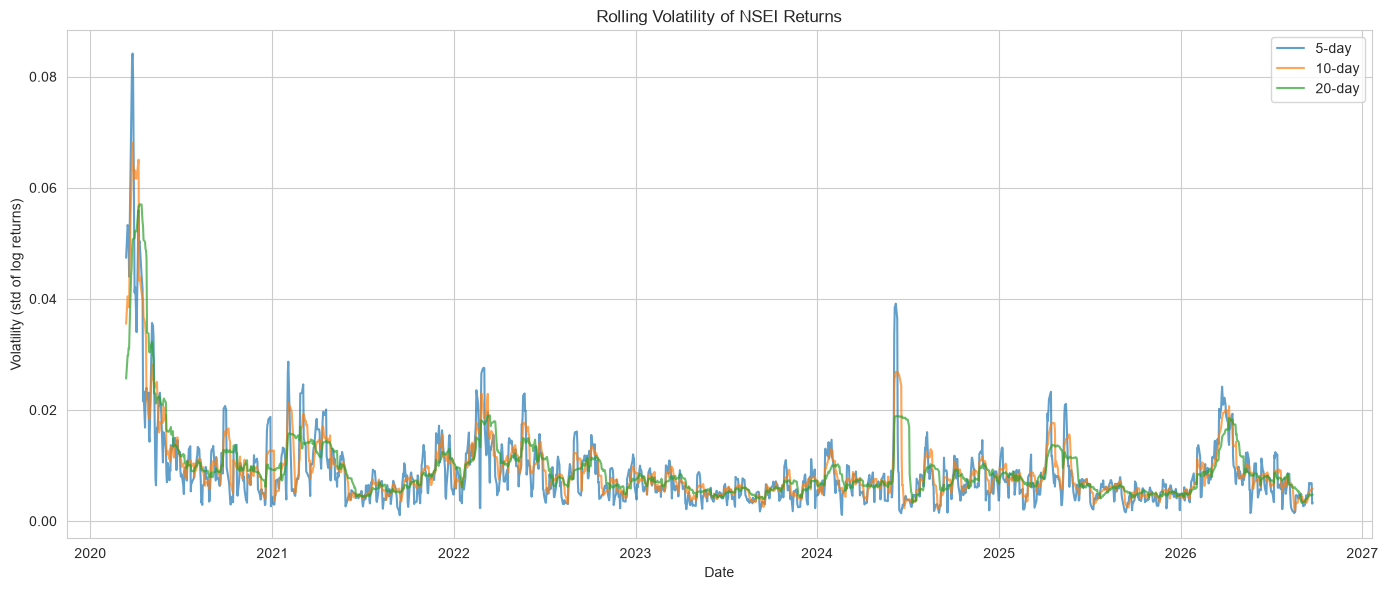

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Vol_rolling_5'], label='5-day', alpha=0.7)
ax.plot(df.index, df['Vol_rolling_10'], label='10-day', alpha=0.7)
ax.plot(df.index, df['Vol_rolling_20'], label='20-day', alpha=0.7)

ax.set_title('Rolling Volatility of NSEI Returns')
ax.set_xlabel('Date'); ax.set_ylabel('Volatility (std of log returns)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_volatility_over_time.png', dpi=120)
plt.show()

3.4 Volume & Range Behavior
Do volume spikes coincide with High–Low range and volatility spikes?

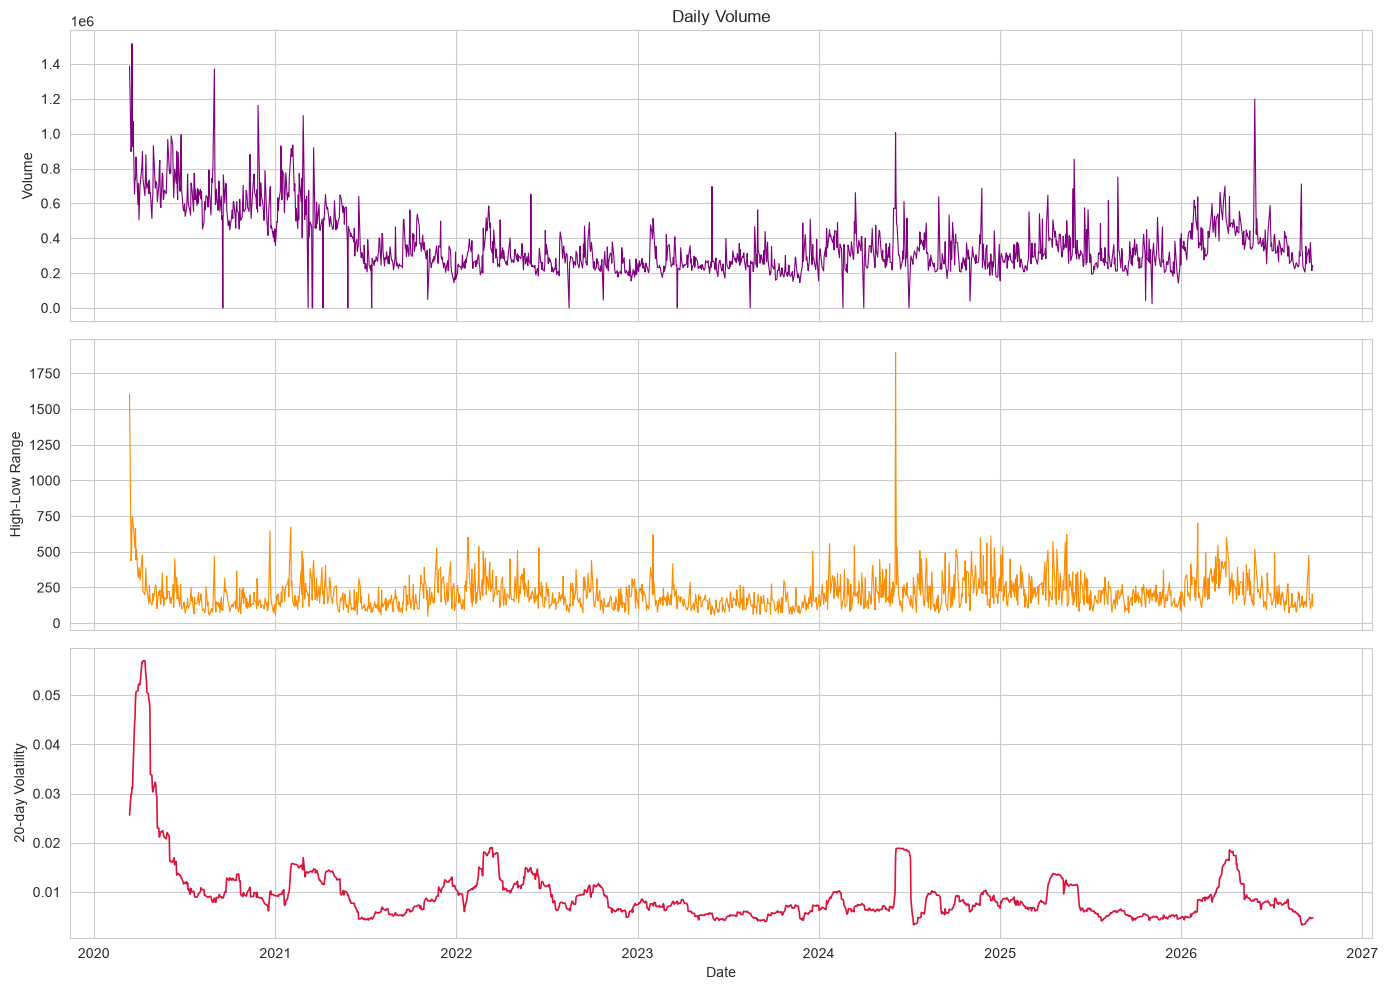

Correlation:
                   Volume  High_Low_Range  Vol_rolling_20
Volume          1.000000        0.313228        0.487270
High_Low_Range  0.313228        1.000000        0.287499
Vol_rolling_20  0.487270        0.287499        1.000000


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Volume'], color='purple', linewidth=0.8)
axes[0].set_ylabel('Volume'); axes[0].set_title('Daily Volume')

axes[1].plot(df.index, df['High_Low_Range'], color='darkorange', linewidth=0.8)
axes[1].set_ylabel('High-Low Range')

axes[2].plot(df.index, df['Vol_rolling_20'], color='crimson', linewidth=1.2)
axes[2].set_ylabel('20-day Volatility')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../reports/figures/04_volume_range_vol.png', dpi=120)
plt.show()

# Correlation
corr = df[['Volume', 'High_Low_Range', 'Vol_rolling_20']].corr()
print("Correlation:\n", corr)

3.4 Volume & Range Behavior
Do volume spikes coincide with High–Low range and volatility spikes?

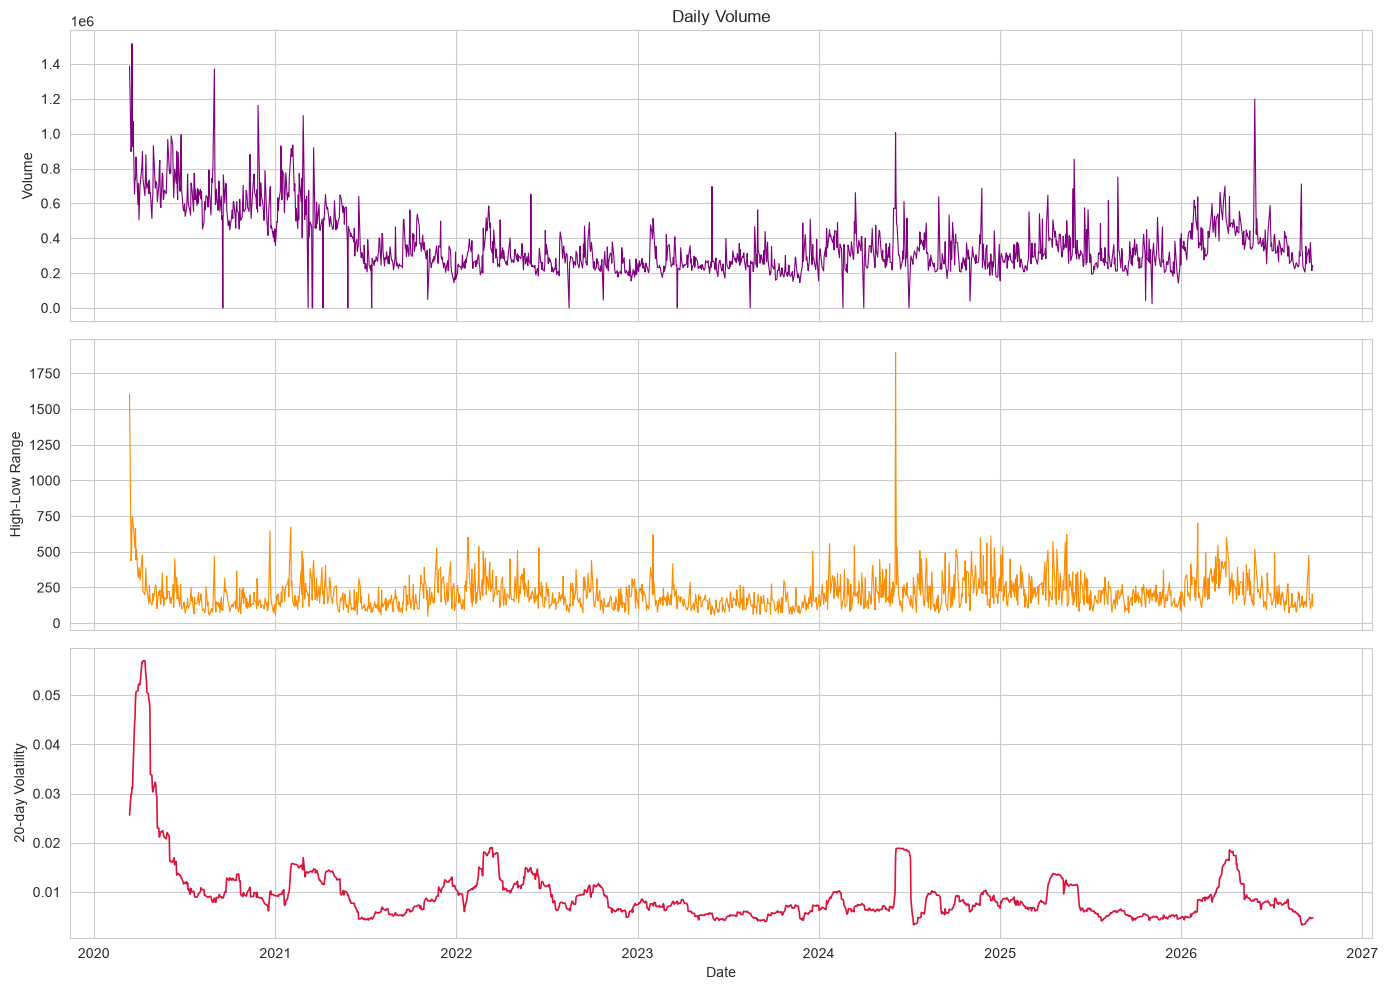

Correlation:
                   Volume  High_Low_Range  Vol_rolling_20
Volume          1.000000        0.313228        0.487270
High_Low_Range  0.313228        1.000000        0.287499
Vol_rolling_20  0.487270        0.287499        1.000000


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Volume'], color='purple', linewidth=0.8)
axes[0].set_ylabel('Volume'); axes[0].set_title('Daily Volume')

axes[1].plot(df.index, df['High_Low_Range'], color='darkorange', linewidth=0.8)
axes[1].set_ylabel('High-Low Range')

axes[2].plot(df.index, df['Vol_rolling_20'], color='crimson', linewidth=1.2)
axes[2].set_ylabel('20-day Volatility')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../reports/figures/04_volume_range_vol.png', dpi=120)
plt.show()

# Correlation
corr = df[['Volume', 'High_Low_Range', 'Vol_rolling_20']].corr()
print("Correlation:\n", corr)

3.5 Correlations
Heatmap of returns, lags, rolling vol, volume, and target. Identify promising features.

Feature correlation with Target_Volatility:


Target_Volatility    1.000000
AbsReturn_roll_5     0.630076
Vol_rolling_10       0.612361
Vol_rolling_5        0.588400
Vol_rolling_20       0.573801
ATR_14               0.488264
Volume_MA_5          0.469207
Volume_MA_20         0.463227
AbsReturn_lag2       0.430847
AbsReturn_lag1       0.429587
AbsReturn_lag5       0.429507
AbsReturn_lag3       0.421647
Volume               0.408775
High_Low_Range       0.333194
Volume_ratio         0.034977
Volume_Change        0.017165
Return_lag10        -0.087572
Return              -0.133172
Return_lag5         -0.134149
Return_lag3         -0.145586
Return_lag2         -0.151799
Return_lag1         -0.165628
RSI_14              -0.210099
MACD_hist           -0.219320
MA_50               -0.275311
MA_20               -0.305448
MA_5                -0.334176
High                -0.338178
Open                -0.341938
Close               -0.344009
Low                 -0.347151
MACD_signal         -0.375094
MACD                -0.419786
Close_MA20

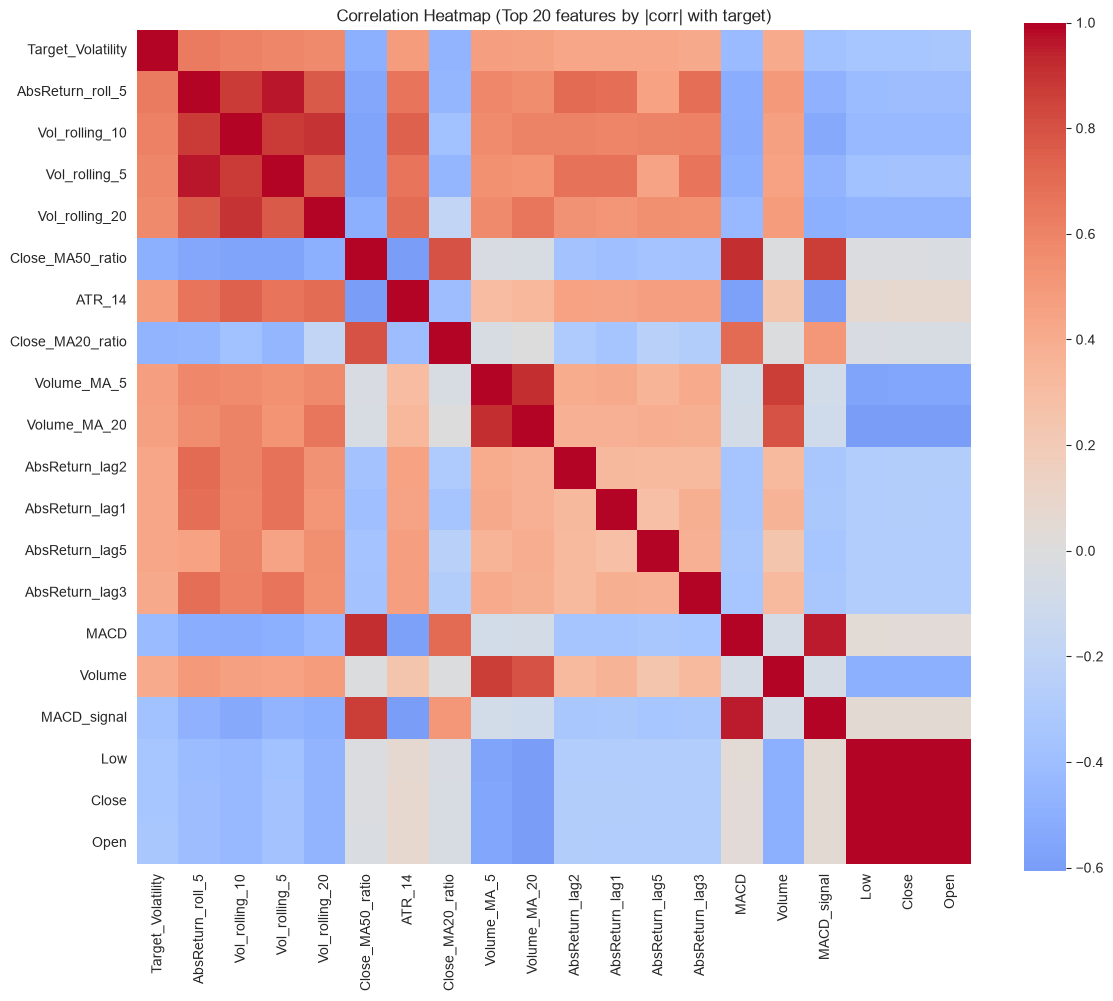

In [13]:
# Correlation with target
target_corr = df.corr(numeric_only=True)['Target_Volatility'].sort_values(ascending=False)
print("Feature correlation with Target_Volatility:")
display(target_corr)

# Full heatmap (top 20 features by abs corr)
top_feats = target_corr.abs().sort_values(ascending=False).head(20).index
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_feats].corr(), cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Correlation Heatmap (Top 20 features by |corr| with target)')
plt.tight_layout()
plt.savefig('../reports/figures/05_correlation_heatmap.png', dpi=120)
plt.show()

3.6 Autocorrelation
ACF of returns vs ACF of squared returns — confirm volatility clustering (squared returns should show strong autocorrelation).

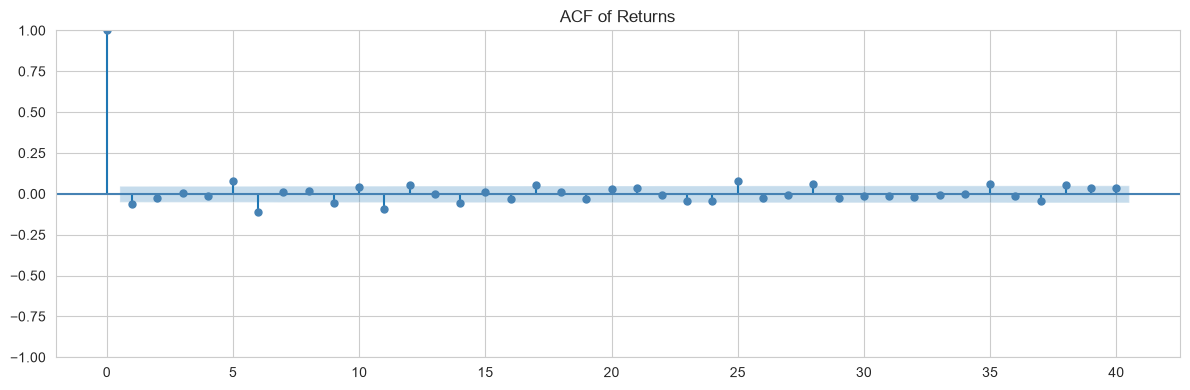

In [14]:
# 3.6a: ACF Returns
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['Return'].dropna(), lags=40, ax=ax, color='steelblue')
ax.set_title('ACF of Returns')
plt.tight_layout()
plt.savefig('../reports/figures/06_acf_returns.png', dpi=120)
plt.show()

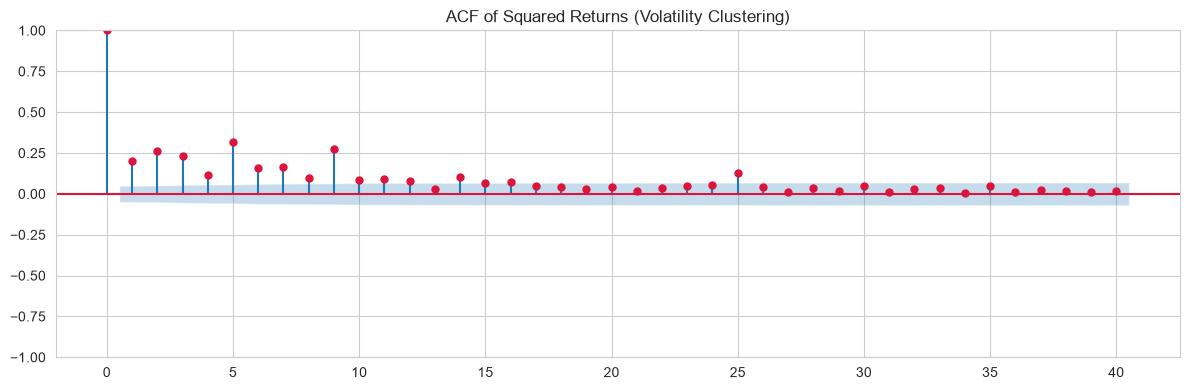

In [15]:
# 3.6b: ACF Squared Returns
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf((df['Return']**2).dropna(), lags=40, ax=ax, color='crimson')
ax.set_title('ACF of Squared Returns (Volatility Clustering)')
plt.tight_layout()
plt.savefig('../reports/figures/07_acf_squared_returns.png', dpi=120)
plt.show()

3.7 Regime Analysis
Classify days into Low / Medium / High volatility regimes using quantiles of 20-day rolling volatility.

In [16]:
# 3.7a: Regime Labels
q1, q2 = df['Vol_rolling_20'].quantile([0.33, 0.66])
def label_regime(v):
    if v <= q1: return 'Low'
    elif v <= q2: return 'Medium'
    else: return 'High'

df['Regime'] = df['Vol_rolling_20'].apply(label_regime)
print(f"Quantile thresholds: Low ≤ {q1:.5f}, Medium ≤ {q2:.5f}")
print(df['Regime'].value_counts())

Quantile thresholds: Low ≤ 0.00649, Medium ≤ 0.00935
Regime
High      548
Medium    532
Low       532
Name: count, dtype: int64


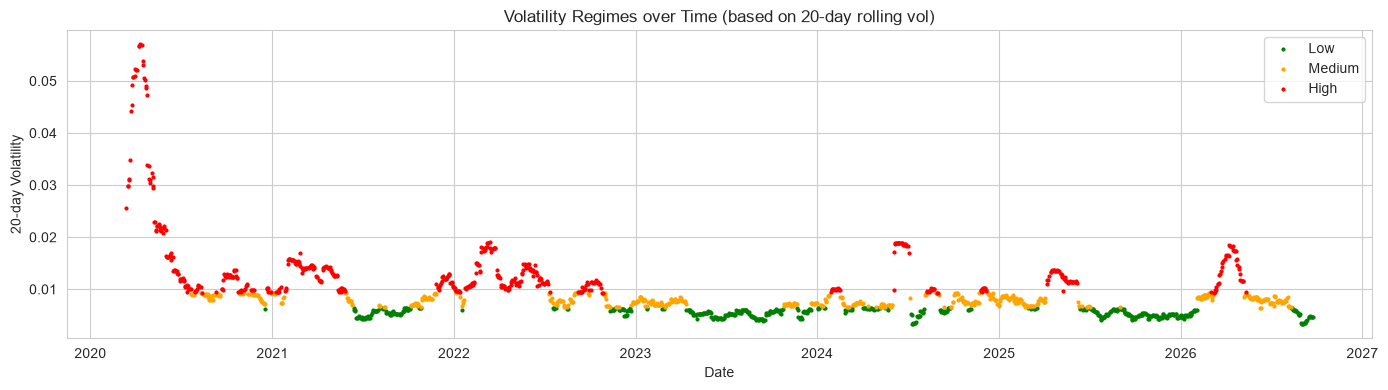

In [17]:
# 3.7b: Regime Over Time
fig, ax = plt.subplots(figsize=(14, 4))
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
for regime, color in colors.items():
    mask = df['Regime'] == regime
    ax.scatter(df.index[mask], df['Vol_rolling_20'][mask], s=4, color=color, label=regime)

ax.set_title('Volatility Regimes over Time (based on 20-day rolling vol)')
ax.set_xlabel('Date'); ax.set_ylabel('20-day Volatility')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_regimes_over_time.png', dpi=120)
plt.show()

In [18]:
# Code - Save with Regime
df.to_csv('../data/processed/nsei_features.csv')
print("Saved updated features file with Regime column.")

Saved updated features file with Regime column.


📋 EDA Insights Summary
Fill these in after running all cells — they become the "Insights" section of your report.

In [19]:
summary = {
    "Date range": f"{df.index.min().date()} → {df.index.max().date()}",
    "Trading days": len(df),
    "Duplicate dates": df.index.duplicated().sum(),
    "Missing values": df.isnull().sum().sum(),
    "Mean daily return": round(df['Return'].mean(), 6),
    "Std daily return": round(df['Return'].std(), 6),
    "Skewness": round(df['Return'].skew(), 4),
    "Excess kurtosis": round(df['Return'].kurtosis(), 4),
    "Best day (return)": f"{df['Return'].idxmax().date()} ({df['Return'].max():.4f})",
    "Worst day (return)": f"{df['Return'].idxmin().date()} ({df['Return'].min():.4f})",
    "Top 3 features by |corr| with target":
        list(target_corr.drop('Target_Volatility').abs().sort_values(ascending=False).head(3).index),
}

for k, v in summary.items():
    print(f"{k}: {v}")

Date range: 2020-03-13 → 2026-09-23
Trading days: 1612
Duplicate dates: 0
Missing values: 0
Mean daily return: 0.000551
Std daily return: 0.011019
Skewness: -1.4168
Excess kurtosis: 22.7452
Best day (return): 2020-04-07 (0.0840)
Worst day (return): 2020-03-23 (-0.1390)
Top 3 features by |corr| with target: ['AbsReturn_roll_5', 'Vol_rolling_10', 'Vol_rolling_5']
